# IQ-TREE — Maximum-likelihood phylogeny of A29L

Builds a maximum-likelihood **gene tree** from the A29L alignment produced by the
earlier pipeline (`A29L_msa_linsi.fasta`).

**This is a gene tree, not a species tree.** It shows the evolutionary history of
the A29L protein, which need not match the history of the viruses carrying it —
recombination, gene loss and limited phylogenetic signal can all cause them to
differ. A29L is only ~110 aa, so deep nodes may be weakly supported. Results
should be described as the history of *this protein*.

**Analyses**

1. **ModelFinder** (`-m MFP`) selects the best-fit substitution model by BIC.
2. **Maximum-likelihood tree** inference under that model.
3. **Branch support** from three independent measures in a single run:
   ultrafast bootstrap (UFBoot, 1000 replicates), SH-aLRT (1000 replicates,
   the minimum the test requires), and the approximate Bayes (aBayes) test.
   The convention adopted here is that a node is well supported when
   **UFBoot ≥ 95 and SH-aLRT ≥ 80**.
4. **Genus-monophyly test** — whether each genus forms a clade in the A29L tree.
   A constrained tree (genera forced monophyletic) is compared against the
   unconstrained ML tree with the **approximately unbiased (AU) test**. Toggle
   with `run_monophyly_test`.
5. **Figures and exports** — a genus-coloured tree figure, and Newick files for
   re-rooting or restyling in iTOL/FigTree.

**Steps**

0. Setup & configuration
1. Verify inputs and tool availability
2. Run IQ-TREE (ModelFinder + ML + supports)
3. Report the selected model and branch support
4. Genus-monophyly test (AU)
5. Genus-coloured tree figure

## Step 0 — Setup & configuration

All parameters live in one frozen `Config`. The alignment is read directly
from Step 1 (`../1_orthologs_msa/output_phase7/`), and the shared FASTA parser
`seqio_utils.py` is imported from the same folder. `iqtree_exe` is the binary name invoked through WSL — set to
`iqtree3`, matching the installed IQ-TREE 3.

Sequence headers follow the `Genus|Accession|Species` convention established in
the curation phase, so genus labels for colouring and for the monophyly
constraint are read directly from the alignment with no external lookup.

Figures are written as PNG at 1000 dpi on a white background. `rcdefaults()` is
called first so that a dark matplotlib style active in the environment cannot
leave text invisible on the white canvas.

In [1]:
from __future__ import annotations

import logging
import re
import subprocess
from collections import defaultdict
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt

import sys

# Shared FASTA parser from Step 1 (single copy in the repository)
sys.path.insert(0, str(Path("../1_orthologs_msa").resolve()))
from seqio_utils import parse_fasta_records

In [2]:
@dataclass(frozen=True)
class Config:
    alignment: Path = Path("../1_orthologs_msa/output_phase7/A29L_msa_linsi.fasta")

    wsl_prefix: list[str] = field(default_factory=lambda: ["wsl"])
    iqtree_exe: str = "iqtree3"

    threads: str = "AUTO"
    ufboot_replicates: int = 1000
    alrt_replicates: int = 1000
    seed: int = 12345

    run_monophyly_test: bool = True
    non_genus_labels: tuple[str, ...] = ("unclassified",)
    min_genus_size: int = 2

    ufboot_threshold: float = 95.0
    alrt_threshold: float = 80.0

    figure_dpi: int = 1000

    out_dir: Path = field(default_factory=lambda: Path("output_iqtree"))

    @property
    def prefix(self) -> Path:
        return self.out_dir / "A29L"

    @property
    def treefile(self) -> Path:
        return self.prefix.with_suffix(".treefile")

    @property
    def contree(self) -> Path:
        return self.prefix.with_suffix(".contree")

    @property
    def iqtree_report(self) -> Path:
        return self.prefix.with_suffix(".iqtree")

    def constraint_tree(self, genus: str) -> Path:
        return self.out_dir / f"constraint_{genus}.nwk"

    def au_prefix(self, genus: str) -> Path:
        return self.out_dir / f"AU_{genus}"

    @property
    def monophyly_csv(self) -> Path:
        return self.out_dir / "genus_monophyly_tests.csv"

    def candidate_trees(self, genus: str) -> Path:
        return self.out_dir / f"candidates_{genus}.nwk"

    @property
    def tree_figure_stem(self) -> Path:
        return self.out_dir / "A29L_ml_tree"

    @property
    def support_csv(self) -> Path:
        return self.out_dir / "branch_support.csv"


CFG = Config()
CFG.out_dir.mkdir(parents=True, exist_ok=True)

matplotlib.rcdefaults()
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[
        logging.StreamHandler(),
        logging.FileHandler(CFG.out_dir / "iqtree_analysis.log"),
    ],
)
log = logging.getLogger("iqtree")

In [3]:
class CommandError(RuntimeError):
    """Raised when an external tool exits with a non-zero status."""


def run_command(cmd: list[str], log_file: Path) -> None:
    log.info("Running: %s", " ".join(cmd))
    with open(log_file, "w", encoding="utf-8") as fh:
        result = subprocess.run(cmd, stdout=fh, stderr=subprocess.STDOUT)
    if result.returncode != 0:
        raise CommandError(
            f"Command failed (exit {result.returncode}): {' '.join(cmd)}. "
            f"See {log_file} for details."
        )

## Step 1 — Verify inputs and tool availability

Confirms the alignment exists, reports its dimensions, and checks that the
IQ-TREE binary responds through WSL. Failing here with a clear message is much
easier to diagnose than a cryptic error part-way through a tree search.

The genus of every sequence is parsed from its header and tallied, giving an
immediate view of how many genera are represented and how many sequences each
contributes — relevant because a genus represented by a single sequence is
trivially monophyletic and is excluded from the constraint test in Step 4.

In [4]:
if not CFG.alignment.exists():
    raise FileNotFoundError(
        f"{CFG.alignment} not found — run Step 1 (1_orthologs_msa) first."
    )

version = subprocess.run(
    CFG.wsl_prefix + [CFG.iqtree_exe, "--version"],
    capture_output=True, text=True,
)
if version.returncode != 0:
    raise CommandError(
        f"'{CFG.iqtree_exe}' did not respond through WSL. Check the binary name "
        f"in Config, and that it is on the PATH inside WSL."
    )
log.info("%s", version.stdout.strip().splitlines()[0])

records = parse_fasta_records(CFG.alignment)


def parse_header(hdr: str) -> tuple[str, str, str]:
    parts = hdr.split("|")
    if len(parts) >= 3:
        return parts[0], parts[1], parts[2]
    return "unclassified", hdr.split()[0], "unclassified"


meta = [parse_header(h) for h, _ in records]
genus_of = {acc: gen for gen, acc, _ in meta}
label_of = {f"{gen}|{acc}|{sp}": acc for gen, acc, sp in meta}

n_seq = len(records)
n_col = len(records[0][1]) if records else 0
genus_counts = defaultdict(int)
for gen, _, _ in meta:
    genus_counts[gen] += 1

log.info("Alignment: %d sequences x %d columns", n_seq, n_col)
log.info("Genera represented: %d", len(genus_counts))
for gen, n in sorted(genus_counts.items(), key=lambda kv: -kv[1]):
    log.info("  %-28s %d", gen, n)

2026-07-25 09:39:45,617 [INFO] IQ-TREE version 3.0.1 for Linux x86 64-bit built May  5 2025
2026-07-25 09:39:45,623 [INFO] Alignment: 60 sequences x 300 columns
2026-07-25 09:39:45,623 [INFO] Genera represented: 15
2026-07-25 09:39:45,628 [INFO]   Parapoxvirus                 16
2026-07-25 09:39:45,628 [INFO]   Orthopoxvirus                14
2026-07-25 09:39:45,628 [INFO]   Capripoxvirus                5
2026-07-25 09:39:45,632 [INFO]   Leporipoxvirus               4
2026-07-25 09:39:45,632 [INFO]   Cervidpoxvirus               4
2026-07-25 09:39:45,632 [INFO]   unclassified                 4
2026-07-25 09:39:45,641 [INFO]   Centapoxvirus                3
2026-07-25 09:39:45,643 [INFO]   Yatapoxvirus                 2
2026-07-25 09:39:45,645 [INFO]   Oryzopoxvirus                2
2026-07-25 09:39:45,646 [INFO]   Sciuripoxvirus               1
2026-07-25 09:39:45,650 [INFO]   Pteropopoxvirus              1
2026-07-25 09:39:45,652 [INFO]   Vespertilionpoxvirus         1
2026-07-25 09:3

## Step 2 — Run IQ-TREE

A single IQ-TREE run performs model selection, tree search and all three branch
tests together, which is both faster and more consistent than separate runs.

- `-m MFP` runs ModelFinder Plus: it evaluates candidate substitution models
  (including rate-heterogeneity variants) and continues with the best by BIC.
- `-B` requests ultrafast bootstrap; `--alrt` requests the SH-aLRT test;
  `--abayes` adds the approximate Bayes test. Supports appear on the tree in
  the order stated in the `.iqtree` report.
- `-T AUTO` lets IQ-TREE choose a thread count appropriate to the data.
- `--seed` fixes the random seed so the run is reproducible.

Checkpointed on the `.treefile`; a re-run skips the search if it already exists.
To force a fresh analysis, delete the `output_iqtree/` folder.

In [5]:
if CFG.treefile.exists():
    log.info("%s exists — skipping IQ-TREE run.", CFG.treefile)
else:
    log.info("Running IQ-TREE (ModelFinder + ML + UFBoot + SH-aLRT + aBayes) ...")
    run_command(
        CFG.wsl_prefix + [
            CFG.iqtree_exe,
            "-s", CFG.alignment.as_posix(),
            "-m", "MFP",
            "-B", str(CFG.ufboot_replicates),
            "--alrt", str(CFG.alrt_replicates),
            "--abayes",
            "-T", CFG.threads,
            "--seed", str(CFG.seed),
            "--prefix", CFG.prefix.as_posix(),
        ],
        log_file=CFG.out_dir / "iqtree_run.log",
    )
    log.info("DONE — tree written to %s", CFG.treefile)

2026-07-25 09:39:46,327 [INFO] Running IQ-TREE (ModelFinder + ML + UFBoot + SH-aLRT + aBayes) ...
2026-07-25 09:39:46,330 [INFO] Running: wsl iqtree3 -s A29L_msa_linsi.fasta -m MFP -B 1000 --alrt 1000 --abayes -T AUTO --seed 12345 --prefix output_iqtree/A29L
2026-07-25 09:46:27,384 [INFO] DONE — tree written to output_iqtree\A29L.treefile


## Step 3 — Selected model and branch support

Reads the `.iqtree` report for the model ModelFinder selected and its BIC, then
parses the support values from the tree.

IQ-TREE writes supports as slash-separated values on each internal node. With
this combination of tests the order is **SH-aLRT / aBayes / UFBoot**. Each node
is scored against the adopted convention (UFBoot ≥ 95 **and** SH-aLRT ≥ 80), and
the counts are summarised — a single sentence that can go directly into a
methods or results section. Per-node values are written to
`branch_support.csv`.

Expect some weakly supported deep nodes: 110 aa carries limited phylogenetic
information, and reporting that honestly is more defensible than presenting a
fully resolved tree.

In [6]:
report = CFG.iqtree_report.read_text(encoding="utf-8")

model_match = re.search(r"Best-fit model according to BIC:\s*(\S+)", report)
best_model = model_match.group(1) if model_match else "not found"
bic_match = re.search(r"Bayesian information criterion \(BIC\) score:\s*([\d.\-]+)", report)
best_bic = bic_match.group(1) if bic_match else "not found"

log.info("Best-fit model (BIC): %s", best_model)
log.info("BIC score: %s", best_bic)

newick = CFG.treefile.read_text(encoding="utf-8")
supports = re.findall(r"\)([\d.]+)/([\d.]+)/([\d.]+):", newick)

rows = []
n_strong = 0
for alrt, abayes, ufboot in supports:
    alrt_v, abayes_v, ufboot_v = float(alrt), float(abayes), float(ufboot)
    strong = ufboot_v >= CFG.ufboot_threshold and alrt_v >= CFG.alrt_threshold
    n_strong += strong
    rows.append((alrt_v, abayes_v, ufboot_v, "Y" if strong else "N"))

import csv
with open(CFG.support_csv, "w", newline="", encoding="utf-8") as fh:
    writer = csv.writer(fh)
    writer.writerow(["node", "SH_aLRT", "aBayes", "UFBoot", "well_supported"])
    for i, r in enumerate(rows, 1):
        writer.writerow([i, *r])

n_nodes = len(rows)
if n_nodes:
    log.info("Internal nodes with support values: %d", n_nodes)
    log.info("Well supported (UFBoot>=%.0f and SH-aLRT>=%.0f): %d (%.1f%%)",
             CFG.ufboot_threshold, CFG.alrt_threshold, n_strong, 100 * n_strong / n_nodes)
    log.info("Per-node values written to %s", CFG.support_csv)
else:
    log.warning("No slash-separated support values found — check the .treefile format.")

2026-07-25 09:46:27,711 [INFO] Best-fit model (BIC): Q.INSECT+F+I+G4
2026-07-25 09:46:27,711 [INFO] BIC score: 14808.5149
2026-07-25 09:46:27,727 [INFO] Internal nodes with support values: 57
2026-07-25 09:46:27,729 [INFO] Well supported (UFBoot>=95 and SH-aLRT>=80): 16 (28.1%)
2026-07-25 09:46:27,729 [INFO] Per-node values written to output_iqtree\branch_support.csv


### Tree parsing helpers

A small Newick reader used by both the monophyly summary and the figure: it
parses the tree into nested nodes, records cumulative branch depth for each,
and assigns vertical positions for drawing. Keeping it in one place means the
monophyly check and the plot operate on exactly the same parsed topology.

In [7]:
def read_newick(path: Path) -> str:
    return path.read_text(encoding="utf-8").strip()


def parse_newick(nwk: str):
    tokens = re.findall(r"[(),;]|[^(),;]+", nwk)
    pos = 0

    def node():
        nonlocal pos
        children = []
        if tokens[pos] == "(":
            pos += 1
            while True:
                children.append(node())
                if tokens[pos] == ",":
                    pos += 1
                    continue
                if tokens[pos] == ")":
                    pos += 1
                    break
        label, length = "", 0.0
        if pos < len(tokens) and tokens[pos] not in "(),;":
            raw = tokens[pos]
            pos += 1
            if ":" in raw:
                label, _, blen = raw.rpartition(":")
                try:
                    length = float(blen)
                except ValueError:
                    length = 0.0
            else:
                label = raw
        return {"children": children, "label": label.strip(), "length": length}

    return node()


def collect_tips(node, acc=None):
    acc = [] if acc is None else acc
    if not node["children"]:
        acc.append(node)
    for ch in node["children"]:
        collect_tips(ch, acc)
    return acc


def assign_depths(node, depth=0.0):
    node["depth"] = depth + node["length"]
    for ch in node["children"]:
        assign_depths(ch, node["depth"])


def layout(node, counter=None):
    counter = [0] if counter is None else counter
    if not node["children"]:
        node["y"] = counter[0]
        counter[0] += 1
    else:
        for ch in node["children"]:
            layout(ch, counter)
        node["y"] = sum(ch["y"] for ch in node["children"]) / len(node["children"])
    return node

## Step 4 — Per-genus monophyly tests (AU)

Tests, **one genus at a time**, whether the A29L tree is consistent with that
genus forming a clade.

A group is *monophyletic* if all its members descend from a single common
ancestor and nothing else does — on a tree, they form one clean clade. For each
genus in turn, a constraint tree forces only **that** genus to be monophyletic
(all other sequences left free), IQ-TREE searches for the best tree satisfying
it, and the **approximately unbiased (AU) test** compares that constrained tree
against the unconstrained ML tree.

- **p-AU > 0.05** — the constrained tree is not significantly worse, so the data
  are consistent with that genus being a clade.
- **p-AU < 0.05** — forcing the genus makes the tree significantly worse: the
  A29L tree conflicts with that genus assignment.

Testing genera separately, rather than all simultaneously, is what makes the
result interpretable: a single combined test that rejects tells you only that
*something* conflicts, not which group.

**Two categories are excluded from testing.** Labels listed in
`non_genus_labels` — here `unclassified` — are not genera at all but sequences
whose genus is unknown; they are unrelated deep-branching lineages that merely
share a missing label, so forcing them into one clade would be biologically
meaningless. Genera with fewer than `min_genus_size` sequences are also skipped,
being trivially monophyletic.

Note that a species-level label of the form `Unclassified_<name>` is unaffected:
those sequences have a known genus (given in the genus field) and are tested with
their genus as normal.

For each **rejected** genus the notebook also reports which of its members sit
outside the genus's largest pure clade in the ML tree. These are the candidate
sequences responsible for the conflict and are the ones worth inspecting first.
Treat this as a diagnostic pointer rather than a verdict: a genus can have a
member attaching outside its main group and still pass the AU test, if the
displacement is not statistically significant. Results are written to
`genus_monophyly_tests.csv`.

> **Interpretation.** This tests whether *the A29L protein's* history is
> consistent with genus assignments. It is not a test of poxvirus taxonomy, and
> a conflict is as likely to reflect recombination, limited signal in a short
> protein, or long-branch attraction as any taxonomic problem.

In [8]:
def constraint_for(genus: str) -> str:
    members = [f"{g}|{a}|{s}" for g, a, s in meta if g == genus]
    others = [f"{g}|{a}|{s}" for g, a, s in meta if g != genus]
    return "((" + ",".join(members) + ")," + ",".join(others) + ");"


def parse_au_table(report_path: Path) -> dict:
    text = report_path.read_text(encoding="utf-8")
    section = text.split("USER TREES")[-1]
    out = {}
    for line in section.splitlines():
        parts = line.split()
        if len(parts) >= 2 and parts[0] in {"1", "2"}:
            numeric = [p for p in parts if re.match(r"^-?[\d.]+(e-?\d+)?$", p)]
            if len(numeric) >= 2:
                out[parts[0]] = {"logL": float(numeric[1]), "p_AU": float(numeric[-1])}
    return out


testable = sorted(
    g for g, n in genus_counts.items()
    if n >= CFG.min_genus_size and g.lower() not in {x.lower() for x in CFG.non_genus_labels}
)
skipped_label = sorted(
    g for g in genus_counts
    if g.lower() in {x.lower() for x in CFG.non_genus_labels}
)
skipped_small = sorted(g for g, n in genus_counts.items() if n < CFG.min_genus_size)

log.info("Genera to test (n>=%d, excluding non-genus labels): %d — %s",
         CFG.min_genus_size, len(testable), testable)
if skipped_label:
    log.info("Excluded as not a genus: %s", skipped_label)
if skipped_small:
    log.info("Skipped (fewer than %d sequences, trivially monophyletic): %s",
             CFG.min_genus_size, skipped_small)

results = []
if not CFG.run_monophyly_test:
    log.info("Monophyly testing disabled in Config — skipping.")
else:
    for genus in testable:
        au_report = CFG.au_prefix(genus).with_suffix(".iqtree")
        if not au_report.exists():
            log.info("Testing monophyly of %s (%d sequences) ...", genus, genus_counts[genus])
            CFG.constraint_tree(genus).write_text(constraint_for(genus), encoding="utf-8")

            con_prefix = CFG.out_dir / f"constrained_{genus}"
            run_command(
                CFG.wsl_prefix + [
                    CFG.iqtree_exe,
                    "-s", CFG.alignment.as_posix(),
                    "-m", best_model,
                    "-g", CFG.constraint_tree(genus).as_posix(),
                    "-T", CFG.threads,
                    "--seed", str(CFG.seed),
                    "--prefix", con_prefix.as_posix(),
                ],
                log_file=CFG.out_dir / f"constrained_{genus}.log",
            )

            ml_nwk = CFG.treefile.read_text(encoding="utf-8").strip()
            con_nwk = con_prefix.with_suffix(".treefile").read_text(encoding="utf-8").strip()
            CFG.candidate_trees(genus).write_text(ml_nwk + "\n" + con_nwk + "\n", encoding="utf-8")

            run_command(
                CFG.wsl_prefix + [
                    CFG.iqtree_exe,
                    "-s", CFG.alignment.as_posix(),
                    "-m", best_model,
                    "-z", CFG.candidate_trees(genus).as_posix(),
                    "-n", "0", "-zb", "10000", "-au",
                    "-T", CFG.threads,
                    "--seed", str(CFG.seed),
                    "--prefix", CFG.au_prefix(genus).as_posix(),
                ],
                log_file=CFG.out_dir / f"autest_{genus}.log",
            )

        table = parse_au_table(au_report)
        p_au = table.get("2", {}).get("p_AU", float("nan"))
        delta = table.get("2", {}).get("logL", float("nan")) - table.get("1", {}).get("logL", float("nan"))
        results.append({
            "genus": genus,
            "n_sequences": genus_counts[genus],
            "delta_logL": round(-delta, 3) if delta == delta else None,
            "p_AU": p_au,
            "monophyletic": "no" if p_au < 0.05 else "yes",
        })

2026-07-25 09:46:27,865 [INFO] Genera to test (n>=2, excluding non-genus labels): 8 — ['Capripoxvirus', 'Centapoxvirus', 'Cervidpoxvirus', 'Leporipoxvirus', 'Orthopoxvirus', 'Oryzopoxvirus', 'Parapoxvirus', 'Yatapoxvirus']
2026-07-25 09:46:27,865 [INFO] Excluded as not a genus: ['unclassified']
2026-07-25 09:46:27,865 [INFO] Skipped (fewer than 2 sequences, trivially monophyletic): ['Avipoxvirus', 'Mustelpoxvirus', 'Pteropopoxvirus', 'Sciuripoxvirus', 'Suipoxvirus', 'Vespertilionpoxvirus']
2026-07-25 09:46:27,872 [INFO] Testing monophyly of Capripoxvirus (5 sequences) ...
2026-07-25 09:46:27,874 [INFO] Running: wsl iqtree3 -s A29L_msa_linsi.fasta -m Q.INSECT+F+I+G4 -g output_iqtree/constraint_Capripoxvirus.nwk -T AUTO --seed 12345 --prefix output_iqtree/constrained_Capripoxvirus
2026-07-25 09:51:06,803 [INFO] Running: wsl iqtree3 -s A29L_msa_linsi.fasta -m Q.INSECT+F+I+G4 -z output_iqtree/candidates_Capripoxvirus.nwk -n 0 -zb 10000 -au -T AUTO --seed 12345 --prefix output_iqtree/AU_Cap

In [9]:
def tips_under(node) -> list[str]:
    if not node["children"]:
        return [node["label"]]
    out = []
    for ch in node["children"]:
        out.extend(tips_under(ch))
    return out


def largest_pure_clade(genus: str, node):
    best = set()

    def walk(n):
        nonlocal best
        labels = tips_under(n)
        genera = {parse_header(l)[0] for l in labels}
        if genera == {genus} and len(labels) > len(best):
            best = set(labels)
        for ch in n["children"]:
            walk(ch)

    walk(node)
    return best


def outliers_for(genus: str, node) -> list[str]:
    members = {f"{g}|{a}|{s}" for g, a, s in meta if g == genus}
    core = largest_pure_clade(genus, node)
    return sorted(members - core)


if results:
    import csv

    root_for_check = parse_newick(CFG.treefile.read_text(encoding="utf-8"))

    for row in results:
        if row["monophyletic"] == "no":
            stray = outliers_for(row["genus"], root_for_check)
            names = sorted(parse_header(s)[1] for s in stray)
            row["outlying_members"] = ";".join(names)
            row["n_outliers"] = len(names)
        else:
            row["outlying_members"] = ""
            row["n_outliers"] = 0

    with open(CFG.monophyly_csv, "w", newline="", encoding="utf-8") as fh:
        writer = csv.DictWriter(fh, fieldnames=[
            "genus", "n_sequences", "delta_logL", "p_AU",
            "monophyletic", "n_outliers", "outlying_members",
        ])
        writer.writeheader()
        writer.writerows(results)

    log.info("Per-genus monophyly results (AU test vs unconstrained ML tree):")
    log.info("  %-24s %5s %11s %12s %s", "genus", "n", "deltaLogL", "p-AU", "monophyletic")
    for row in sorted(results, key=lambda r: r["p_AU"]):
        log.info("  %-24s %5d %11.2f %12.3g %s",
                 row["genus"], row["n_sequences"], row["delta_logL"] or 0.0,
                 row["p_AU"], row["monophyletic"])

    rejected = [r for r in results if r["monophyletic"] == "no"]
    supported = [r for r in results if r["monophyletic"] == "yes"]
    log.info("Consistent with monophyly: %d/%d genera — %s",
             len(supported), len(results), sorted(r["genus"] for r in supported))
    if rejected:
        log.info("Rejected (A29L tree conflicts with the genus):")
        for r in rejected:
            log.info("  %s (p-AU=%.3g) — member(s) outside the main clade: %s",
                     r["genus"], r["p_AU"], r["outlying_members"] or "(none identified)")
    log.info("Table written to %s", CFG.monophyly_csv)

2026-07-25 10:43:06,932 [INFO] Per-genus monophyly results (AU test vs unconstrained ML tree):
2026-07-25 10:43:06,936 [INFO]   genus                        n   deltaLogL         p-AU monophyletic
2026-07-25 10:43:06,938 [INFO]   Cervidpoxvirus               4        0.00        0.361 yes
2026-07-25 10:43:06,940 [INFO]   Centapoxvirus                3        3.21        0.382 yes
2026-07-25 10:43:06,942 [INFO]   Leporipoxvirus               4        2.70        0.383 yes
2026-07-25 10:43:06,945 [INFO]   Yatapoxvirus                 2        2.70         0.39 yes
2026-07-25 10:43:06,946 [INFO]   Oryzopoxvirus                2        1.25        0.402 yes
2026-07-25 10:43:06,947 [INFO]   Orthopoxvirus               14        1.24        0.405 yes
2026-07-25 10:43:06,949 [INFO]   Capripoxvirus                5        0.00        0.413 yes
2026-07-25 10:43:06,950 [INFO]   Parapoxvirus                16        0.92        0.427 yes
2026-07-25 10:43:06,952 [INFO] Consistent with monophyly: 8

## Step 5 — Genus-coloured tree figure

Renders the ML tree with tips coloured by genus. The tree is **midpoint-rooted**
for display only — a neutral choice that assumes nothing beyond placing the root
at the midpoint of the longest tip-to-tip path. The Newick files written by
IQ-TREE are unrooted, so any rooting can be applied later in iTOL or FigTree.

Well-supported nodes (UFBoot ≥ 95 and SH-aLRT ≥ 80) are marked, so the figure
carries its own support information rather than requiring the reader to consult
the CSV.

Exports: `A29L_ml_tree.png` at 1000 dpi, plus the Newick trees already written
by IQ-TREE (`.treefile` with supports, `.contree` consensus) for external
rendering.

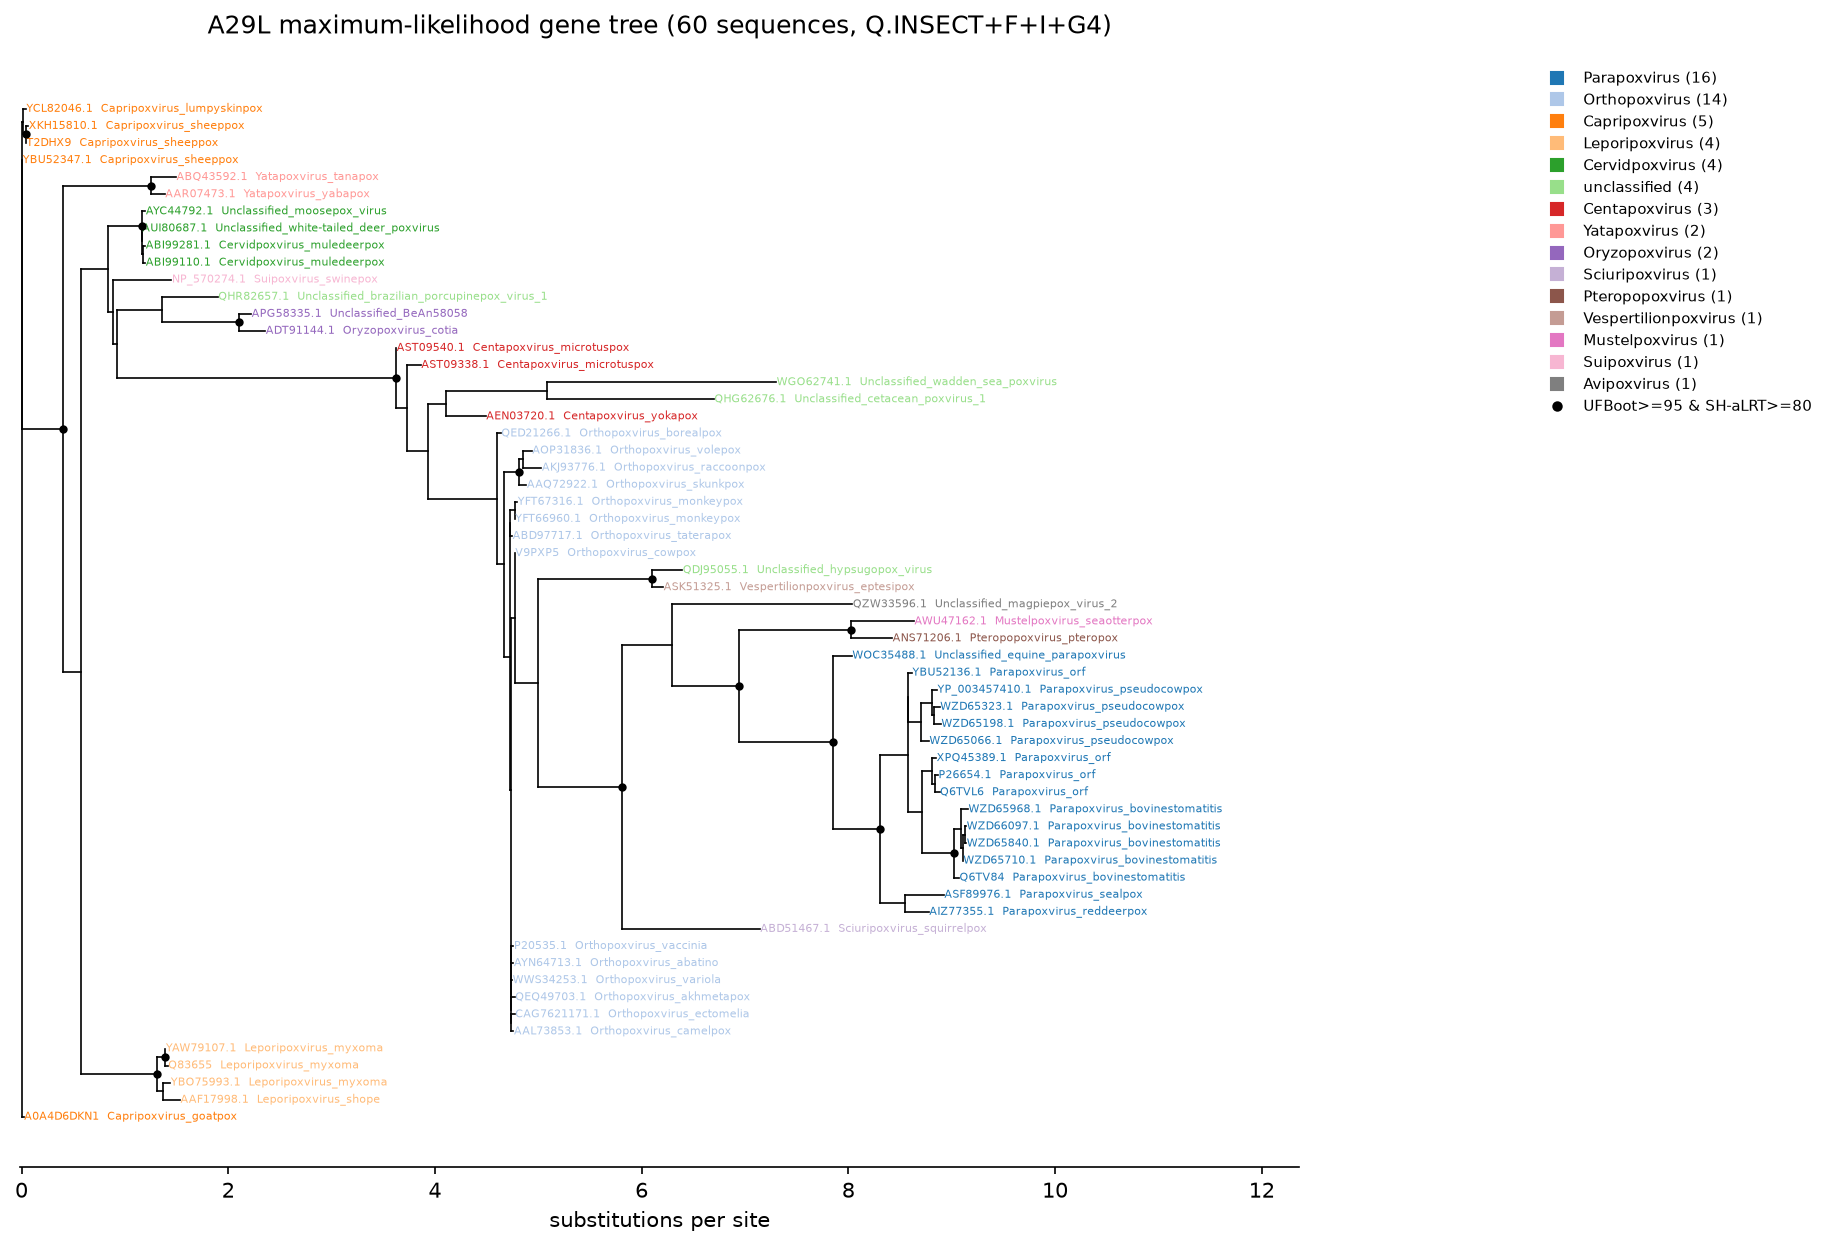

2026-07-25 10:43:21,104 [INFO] DONE — tree figure saved to output_iqtree\A29L_ml_tree.png
2026-07-25 10:43:21,149 [INFO] Newick for iTOL/FigTree: output_iqtree\A29L.treefile (supports), output_iqtree\A29L.contree (consensus)
2026-07-25 10:43:21,150 [INFO] IQ-TREE analysis complete. Outputs in output_iqtree


In [10]:
root = parse_newick(read_newick(CFG.treefile))
assign_depths(root)
layout(root)
tips = collect_tips(root)

palette = plt.get_cmap("tab20")
genera_sorted = sorted(genus_counts, key=lambda g: -genus_counts[g])
colour_of = {g: palette(i % 20) for i, g in enumerate(genera_sorted)}

fig_height = max(6.0, 0.16 * len(tips))
fig, ax = plt.subplots(figsize=(11, fig_height), dpi=150)


def draw(node):
    if node["children"]:
        ys = [ch["y"] for ch in node["children"]]
        ax.plot([node["depth"]] * 2, [min(ys), max(ys)], color="black", lw=0.8)
        for ch in node["children"]:
            ax.plot([node["depth"], ch["depth"]], [ch["y"]] * 2, color="black", lw=0.8)
            draw(ch)
        parts = node["label"].split("/")
        if len(parts) == 3:
            try:
                if float(parts[2]) >= CFG.ufboot_threshold and float(parts[0]) >= CFG.alrt_threshold:
                    ax.plot(node["depth"], node["y"], marker="o", ms=3.0,
                            color="black", zorder=5)
            except ValueError:
                pass


draw(root)

for tip in tips:
    gen, acc, sp = parse_header(tip["label"])
    ax.text(tip["depth"] + 0.005, tip["y"], f"{acc}  {sp}",
            va="center", fontsize=5.5, color=colour_of.get(gen, "black"))

handles = [plt.Line2D([], [], color=colour_of[g], marker="s", ls="",
                      label=f"{g} ({genus_counts[g]})") for g in genera_sorted]
handles.append(plt.Line2D([], [], color="black", marker="o", ls="", ms=4,
                          label=f"UFBoot>={CFG.ufboot_threshold:.0f} & SH-aLRT>={CFG.alrt_threshold:.0f}"))
ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.18, 1.0),
          fontsize=7, frameon=False)

ax.set_xlabel("substitutions per site", fontsize=10)
ax.set_yticks([])
ax.set_title(f"A29L maximum-likelihood gene tree ({n_seq} sequences, {best_model})",
             fontsize=12, pad=12)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.set_xlim(-0.01, max(t["depth"] for t in tips) * 1.35)

fig.savefig(CFG.tree_figure_stem.with_suffix(".png"), dpi=CFG.figure_dpi,
            bbox_inches="tight", facecolor="white")
plt.show()

log.info("DONE — tree figure saved to %s", CFG.tree_figure_stem.with_suffix(".png"))
log.info("Newick for iTOL/FigTree: %s (supports), %s (consensus)",
         CFG.treefile, CFG.contree)
log.info("IQ-TREE analysis complete. Outputs in %s", CFG.out_dir)